In [6]:
!unzip archive.zip

Archive:  archive.zip
  inflating: NEU-DET/train/annotations/crazing_1.xml  
  inflating: NEU-DET/train/annotations/crazing_10.xml  
  inflating: NEU-DET/train/annotations/crazing_100.xml  
  inflating: NEU-DET/train/annotations/crazing_101.xml  
  inflating: NEU-DET/train/annotations/crazing_102.xml  
  inflating: NEU-DET/train/annotations/crazing_103.xml  
  inflating: NEU-DET/train/annotations/crazing_104.xml  
  inflating: NEU-DET/train/annotations/crazing_105.xml  
  inflating: NEU-DET/train/annotations/crazing_106.xml  
  inflating: NEU-DET/train/annotations/crazing_107.xml  
  inflating: NEU-DET/train/annotations/crazing_108.xml  
  inflating: NEU-DET/train/annotations/crazing_109.xml  
  inflating: NEU-DET/train/annotations/crazing_11.xml  
  inflating: NEU-DET/train/annotations/crazing_110.xml  
  inflating: NEU-DET/train/annotations/crazing_111.xml  
  inflating: NEU-DET/train/annotations/crazing_112.xml  
  inflating: NEU-DET/train/annotations/crazing_113.xml  
  inflating: 

In [7]:
import os
import math
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [8]:
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [9]:
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 20
AUTOTUNE = tf.data.AUTOTUNE

In [10]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "NEU-DET/train/images",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print("Classes:", class_names)

Found 1440 files belonging to 6 classes.
Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


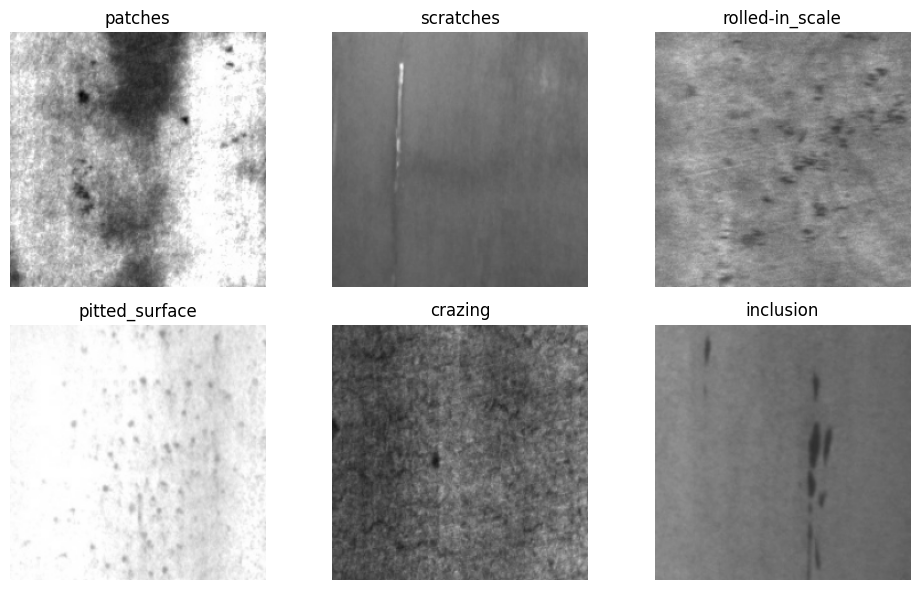

In [11]:
plt.figure(figsize=(10,6))

shown_classes = set()
i = 1

for images, labels in train_ds.unbatch():
    class_idx = np.argmax(labels.numpy())

    if class_idx not in shown_classes:
        plt.subplot(2,3,i)
        plt.imshow(images.numpy().astype("uint8"))
        plt.title(class_names[class_idx])
        plt.axis("off")

        shown_classes.add(class_idx)
        i += 1

    if len(shown_classes) == 6:
        break

plt.tight_layout()
plt.show()

In [12]:
val_full = tf.keras.utils.image_dataset_from_directory(
    "NEU-DET/validation/images",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True
)

Found 360 files belonging to 6 classes.


In [13]:
val_images = []
val_labels = []

for img_batch, label_batch in val_full:
    val_images.append(img_batch)
    val_labels.append(label_batch)

val_images = tf.concat(val_images, axis=0)
val_labels = tf.concat(val_labels, axis=0)

X_val, X_test, y_val, y_test = train_test_split(
    val_images.numpy(),
    val_labels.numpy(),
    test_size=0.5,
    random_state=42,
    stratify=np.argmax(val_labels.numpy(), axis=1)
)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)

In [14]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
])

In [15]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu",
                 kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
x = layers.Dropout(0.6)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs, outputs)
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,049 (16.70 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [30]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    verbose=1
)

In [31]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 20s 82ms/step - accuracy: 0.9856 - loss: 0.5924 - val_accuracy: 0.9556 - val_loss: 0.6686 - learning_rate: 3.0000e-04
Epoch 2/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.9802 - loss: 0.5957 - val_accuracy: 0.9222 - val_loss: 0.6908 - learning_rate: 3.0000e-04
Epoch 3/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.9875 - loss: 0.5829 - val_accuracy: 0.9278 - val_loss: 0.7034 - learning_rate: 3.0000e-04
Epoch 4/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.9852 - loss: 0.5811 - val_accuracy: 0.9500 - val_loss: 0.6554 - learning_rate: 3.0000e-04
Epoch 5/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.9888 - loss: 0.5839 - val_accuracy: 0.9333 - val_loss: 0.6577 - learning_rate: 3.0000e-04
Epoch 6/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.9879 - loss: 0.5862 - val_accuracy: 0.9500 - val_loss: 0.6455 - learning_rate: 3.0000e-04
Epoch 7/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.9933

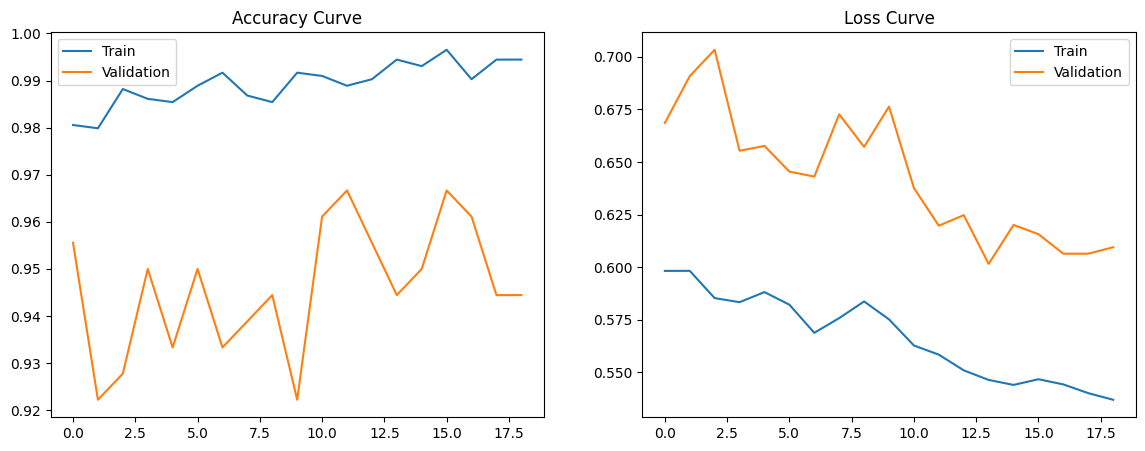

In [32]:
plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title("Accuracy Curve")

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.legend()
plt.title("Loss Curve")

plt.show()

In [33]:
y_true_val = []
y_pred_val = []

for images_batch, labels_batch in val_ds:
    preds = model.predict(images_batch, verbose=0)
    y_true_val.extend(np.argmax(labels_batch.numpy(), axis=1))
    y_pred_val.extend(np.argmax(preds, axis=1))

print("Validation Classification Report:\n")
print(classification_report(y_true_val, y_pred_val, target_names=class_names))

Validation Classification Report:

                 precision    recall  f1-score   support

        crazing       0.97      1.00      0.98        30
      inclusion       0.88      0.97      0.92        30
        patches       1.00      1.00      1.00        30
 pitted_surface       1.00      0.93      0.97        30
rolled-in_scale       0.88      1.00      0.94        30
      scratches       0.96      0.77      0.85        30

       accuracy                           0.94       180
      macro avg       0.95      0.94      0.94       180
   weighted avg       0.95      0.94      0.94       180



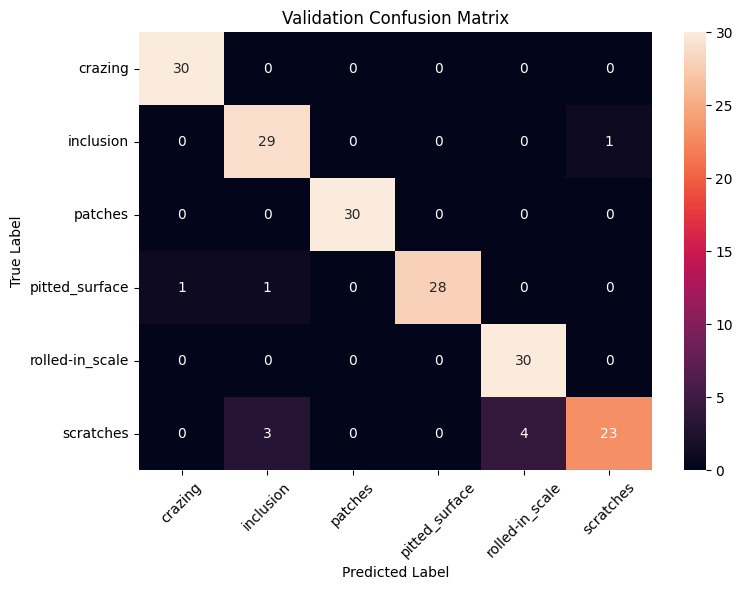

In [34]:
cm_val = confusion_matrix(y_true_val, y_pred_val)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm_val,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Validation Confusion Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [35]:
test_loss, test_accuracy = model.evaluate(test_ds)
print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.9277 - loss: 0.6215
Test Accuracy: 0.949999988079071
Test Loss: 0.5936034321784973


In [36]:
y_true_test = []
y_pred_test = []

for images_batch, labels_batch in test_ds:
    preds = model.predict(images_batch, verbose=0)
    y_true_test.extend(np.argmax(labels_batch.numpy(), axis=1))
    y_pred_test.extend(np.argmax(preds, axis=1))

print(classification_report(y_true_test, y_pred_test, target_names=class_names))

                 precision    recall  f1-score   support

        crazing       0.97      1.00      0.98        30
      inclusion       0.94      1.00      0.97        30
        patches       1.00      1.00      1.00        30
 pitted_surface       1.00      0.87      0.93        30
rolled-in_scale       0.83      1.00      0.91        30
      scratches       1.00      0.83      0.91        30

       accuracy                           0.95       180
      macro avg       0.96      0.95      0.95       180
   weighted avg       0.96      0.95      0.95       180



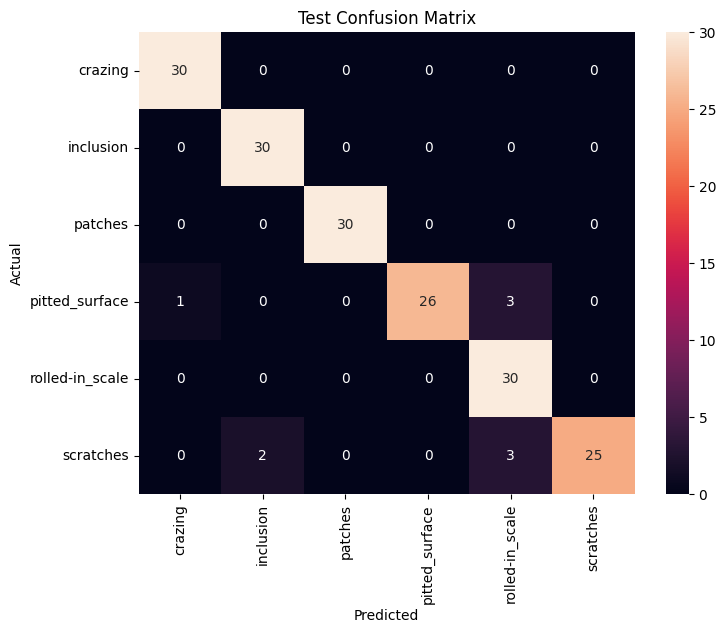

In [37]:
cm = confusion_matrix(y_true_test, y_pred_test)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Test Confusion Matrix")
plt.show()

In [38]:
misclassified = []

for images_batch, labels_batch in test_ds:
    preds = model.predict(images_batch, verbose=0)
    for i in range(len(images_batch)):
        true_label = np.argmax(labels_batch[i])
        pred_label = np.argmax(preds[i])
        if true_label != pred_label:
            misclassified.append(
                (images_batch[i].numpy(), true_label, pred_label)
            )

print("Total Misclassified:", len(misclassified))

Total Misclassified: 9


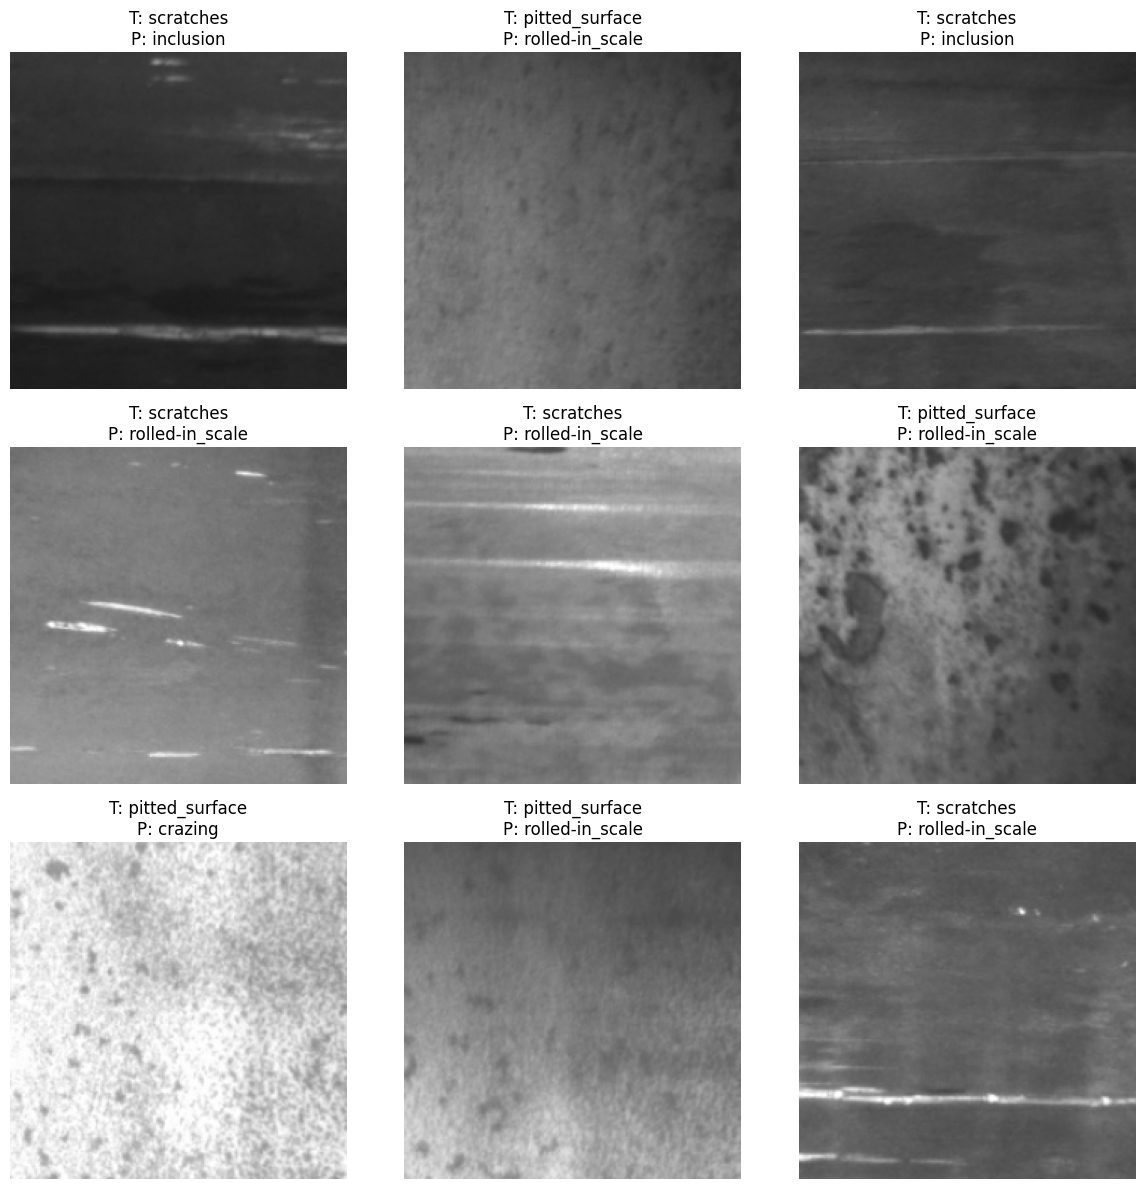

In [39]:
cols = 3
rows = math.ceil(len(misclassified) / cols)

plt.figure(figsize=(4*cols, 4*rows))

for i in range(len(misclassified)):
    img, true_label, pred_label = misclassified[i]
    plt.subplot(rows, cols, i+1)
    plt.imshow(img.astype("uint8"))
    plt.title(f"T: {class_names[true_label]}\nP: {class_names[pred_label]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [40]:
# Save model in modern format
model.save("steel_defect_model.keras")

import json
with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print("Model and class names saved successfully.")

Model and class names saved successfully.


In [41]:
# Model Prediction

import tensorflow as tf
import numpy as np
import json
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from google.colab import files

IMG_SIZE = 224

# Load model
model = tf.keras.models.load_model("steel_defect_model.keras")

# Load class names
with open("class_names.json", "r") as f:
    class_names = json.load(f)

print("Model and class names loaded successfully.")

Model and class names loaded successfully.


In [42]:
import pandas as pd

def predict_image(img_path):

    # Load image
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    # Preprocess
    img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)

    # Predict
    preds = model.predict(img_array)[0]

    predicted_index = np.argmax(preds)
    predicted_class = class_names[predicted_index]
    confidence = float(np.max(preds))

    df = pd.DataFrame({
    "Class": class_names,
    "Probability": preds,
    "Percentage (%)": preds * 100
    })

    # Round BOTH columns properly
    df["Probability"] = df["Probability"].round(4)
    df["Percentage (%)"] = df["Percentage (%)"].round(4)

    df = df.sort_values(by="Probability", ascending=False).reset_index(drop=True)

    # Display Image
    plt.imshow(img)
    plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.4f}")
    plt.axis("off")
    plt.show()

    print("\nPrediction Table:\n")
    display(df)

    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


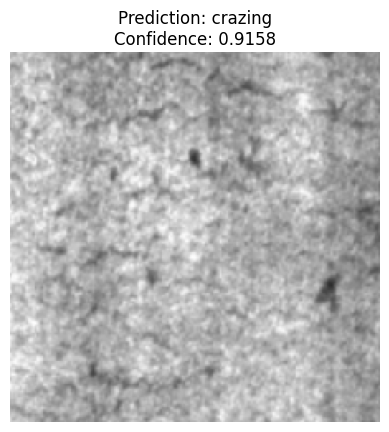


Prediction Table:



,Class,Probability,Percentage (%)
0,crazing,0.9158,91.584602
1,pitted_surface,0.0234,2.335100
2,rolled-in_scale,0.0218,2.183500
3,patches,0.0173,1.731300
4,scratches,0.0124,1.243900
5,inclusion,0.0092,0.921700


('crazing', 0.9158455729484558)

In [43]:
predict_image("crazing.png")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


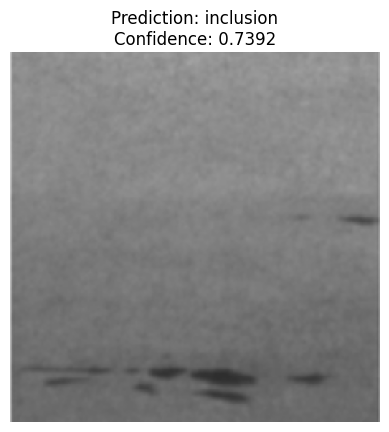


Prediction Table:



,Class,Probability,Percentage (%)
0,inclusion,0.7392,73.924698
1,rolled-in_scale,0.1507,15.069400
2,scratches,0.0381,3.805700
3,patches,0.0306,3.063800
4,pitted_surface,0.0304,3.036100
5,crazing,0.0110,1.100300


('inclusion', 0.7392469644546509)

In [44]:
predict_image("inclusion.png")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


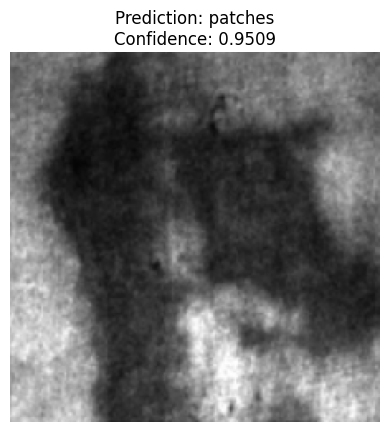


Prediction Table:



,Class,Probability,Percentage (%)
0,patches,0.9509,95.087097
1,inclusion,0.0143,1.434300
2,scratches,0.0107,1.069500
3,rolled-in_scale,0.0091,0.908000
4,crazing,0.0083,0.826100
5,pitted_surface,0.0068,0.675100


('patches', 0.9508708119392395)

In [45]:
predict_image("patches.png")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


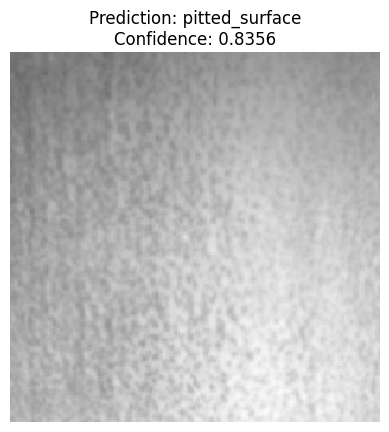


Prediction Table:



,Class,Probability,Percentage (%)
0,pitted_surface,0.8356,83.557503
1,inclusion,0.0570,5.700400
2,crazing,0.0568,5.684800
3,patches,0.0203,2.031400
4,scratches,0.0182,1.820100
5,rolled-in_scale,0.0121,1.206000


('pitted_surface', 0.8355746269226074)

In [47]:
predict_image("pitted surface.png")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


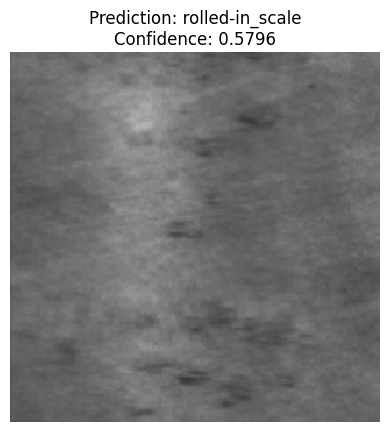


Prediction Table:



,Class,Probability,Percentage (%)
0,rolled-in_scale,0.5796,57.958801
1,inclusion,0.1695,16.953800
2,patches,0.1444,14.440100
3,pitted_surface,0.0426,4.255300
4,scratches,0.0388,3.876600
5,crazing,0.0252,2.515400


('rolled-in_scale', 0.5795877575874329)

In [48]:
predict_image("rolled in.png")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


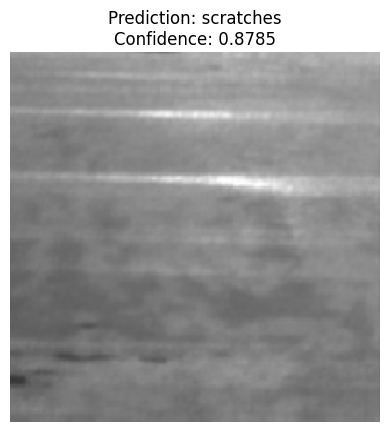


Prediction Table:



,Class,Probability,Percentage (%)
0,scratches,0.8785,87.851997
1,rolled-in_scale,0.0491,4.905900
2,patches,0.0212,2.120900
3,crazing,0.0198,1.982000
4,inclusion,0.0190,1.896500
5,pitted_surface,0.0124,1.242800


('scratches', 0.8785196542739868)

In [49]:
predict_image("scraches.png")

In [50]:
!zip -r all_files.zip /content

  adding: content/ (stored 0%)
  adding: content/.config/ (stored 0%)
  adding: content/.config/logs/ (stored 0%)
  adding: content/.config/logs/2026.02.06/ (stored 0%)
  adding: content/.config/logs/2026.02.06/14.31.45.734270.log (deflated 56%)
  adding: content/.config/logs/2026.02.06/14.31.28.771044.log (deflated 86%)
  adding: content/.config/logs/2026.02.06/14.31.19.332851.log (deflated 58%)
  adding: content/.config/logs/2026.02.06/14.31.35.535753.log (deflated 58%)
  adding: content/.config/logs/2026.02.06/14.30.32.592228.log (deflated 92%)
  adding: content/.config/logs/2026.02.06/14.31.44.938153.log (deflated 57%)
  adding: content/.config/.last_update_check.json (deflated 25%)
  adding: content/.config/configurations/ (stored 0%)
  adding: content/.config/configurations/config_default (deflated 15%)
  adding: content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db (deflated 97%)
  adding: content/.config/.last_survey_prompt.yaml (stored 0%)
  adding: co

In [51]:
from google.colab import files
files.download('all_files.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>